In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [54]:
dir_data = '/Users/jgomezvelez/Downloads/aorc_data'

filename_data = 'data_site_01491000.csv'
filename_meta = 'metadata_site_01491000.csv'

df_data = pd.read_csv(os.path.join(dir_data, filename_data))
df_data['dateTime'] = pd.to_datetime(df_data['dateTime'], format='mixed', errors='coerce')

df_meta = pd.read_csv(
    os.path.join(dir_data, filename_meta),
    encoding='ISO-8859-1',
    dtype={'statistic_id': str, 'parameter_code': str}
)

print(df_data.head())
print(df_meta.head())



/var/folders/1k/8y9ldgnn7_56nc6rxpw68kt00000gq/T/ipykernel_96986/4230526579.py:6: DtypeWarning: Columns (4,8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv(os.path.join(dir_data, filename_data))


  agency_cd  site_no            dateTime  X_00010_00000 X_00010_00000_cd  \
0      USGS  1491000 1990-10-01 05:08:00            NaN              NaN   
1      USGS  1491000 1990-10-01 05:23:00            NaN              NaN   
2      USGS  1491000 1990-10-01 05:38:00            NaN              NaN   
3      USGS  1491000 1990-10-01 05:53:00            NaN              NaN   
4      USGS  1491000 1990-10-01 06:08:00            NaN              NaN   

   X_00060_00000 X_00060_00000_cd  X_00065_00000 X_00065_00000_cd  \
0           21.0           A [91]            NaN              NaN   
1           21.0           A [91]            NaN              NaN   
2           21.0           A [91]            NaN              NaN   
3           21.0           A [91]            NaN              NaN   
4           21.0           A [91]            NaN              NaN   

   X_99133_00000 X_99133_00000_cd tz_cd  
0            NaN              NaN   UTC  
1            NaN              NaN   UTC  
2 

In [55]:
parameter_name = df_meta['parameter_name'] + ' [' + df_meta['unit_of_measure'] + ']'
parameter_code = df_meta['parameter_code']

col_rename = {}

for pcode, pname in zip(parameter_code, parameter_name):

    val_cols = [cn for cn in df_data.columns if (pcode in cn) and ("cd" not in cn)]

    if len(val_cols) == 1:
        col_rename[val_cols[0]] = pname


col_rename

the_cols = ["dateTime"] + list(col_rename.keys()) + ["tz_cd"]
df_data_ready = df_data[the_cols].rename(columns=col_rename)


In [59]:
df_data_ready.columns

Index(['dateTime', 'NO3+NO2,water,insitu as N [mg/l]',
       'Temperature, water [degC]', 'Discharge [ft^3/s]', 'Gage height [ft]',
       'tz_cd'],
      dtype='object')

<Axes: xlabel='dateTime', ylabel='NO3+NO2,water,insitu as N [mg/l]'>

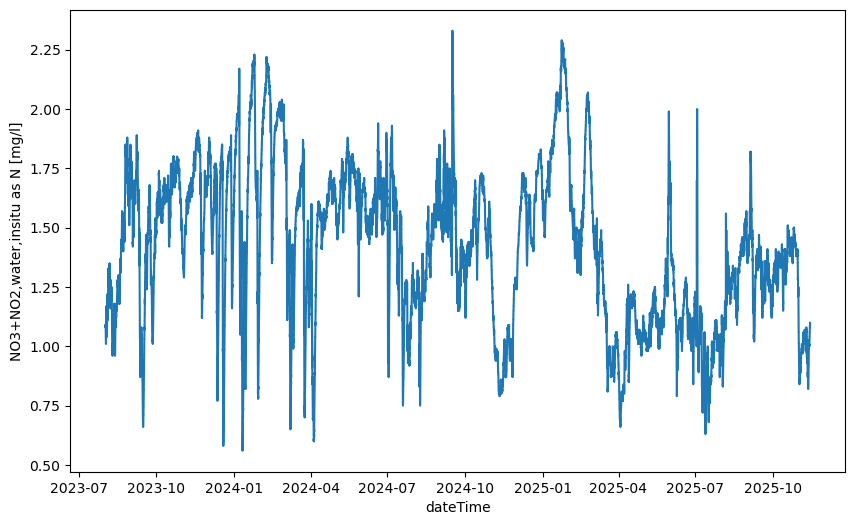

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    x='dateTime',
    y='NO3+NO2,water,insitu as N [mg/l]',
    data=df_data_ready,
    ax=ax
)




In [53]:
df_data_ready['dateTime']

0         1990-10-01 05:08:00
1         1990-10-01 05:23:00
2         1990-10-01 05:38:00
3         1990-10-01 05:53:00
4         1990-10-01 06:08:00
                  ...        
1199019   2025-11-14 01:10:00
1199020   2025-11-14 01:15:00
1199021   2025-11-14 01:20:00
1199022   2025-11-14 01:25:00
1199023   2025-11-14 01:30:00
Name: dateTime, Length: 1199024, dtype: datetime64[ns]

In [24]:
the_cols = ["dateTime"] + [ "X_" + pcode + "_00000" for pcode in parameter_code] + ["tz_cd"]
df_data[the_cols]

KeyError: "['X_72213_00000', 'X_00665_00000'] not in index"

In [8]:
df_meta['parameter_name']

NO3+NO2,water,insitu as N      mg/l
Turbidity, FBRU               _FBRU
Temperature, water             degC
Discharge                    ft^3/s
Temperature, water             degC
Phosphorus, wu as P            mg/l
Gage height                      ft
Name: parameter_name, dtype: object

In [6]:
df_meta['unit_of_measure']

NO3+NO2,water,insitu as N    11
Turbidity, FBRU              11
Temperature, water           11
Discharge                    11
Temperature, water           11
Phosphorus, wu as P          11
Gage height                  11
Name: unit_of_measure, dtype: int64